# Study of DIS process

In this section we are going to reconstruct the DIS variables $x_B$ and $Q^2$, check how well they are
reconstructed and investigate correlations.

## Preparing list of files to be processed

In [1]:
#Import some packages we'll need
import uproot as up
import os
import awkward as ak
import numpy as np
import pandas as pd
import scipy
import math
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.pylab as plt
import vector
from XRootD import client
from scipy import stats
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import colors as colours

We are going to download a list of 5 files to process at a later stage.
We start by investigating collisions of electrons and protons, where the electrons have an energy of 5 GeV 
and the protons have an energy of 41 GeV. We will place these files into the directory input_5x41, which we need to create first.
We place the names of downloaded files into a list so that they can be easily processed.

In [2]:
eic_server = 'root://dtn-eic.jlab.org/'
fs = client.FileSystem(eic_server)
fpath = '/volatile/eic/EPIC/RECO/25.04.1/epic_craterlake/DIS/NC/5x41/minQ2=1/'
status, files = fs.dirlist(fpath)
inflist=[] # Contains list of input files 
flist=[] # prepare list of locally copied input files we will process

if status.ok: # Check we can see our files and connect OK
    #Add files to our list flist
    i=0
    for entry in files:
        if i<5:
            inflist.append(eic_server+fpath+entry.name) # Add all of our entries to a new list, flist
            i+=1

    #Download files from our list    
    i=0        
    for entry in sorted(inflist):
        #print(entry)
        i+=1
        fname="/home/jovyan/eic/input_5x41/input"+str(i)+".root" #File name for downoladed files. Change this if you want
        #print(fname)
        flist.append(fname)
        if os.path.isfile(fname):#Check if file already downloaded
            print("File existing")
        else:
            print(entry)
            print("Downloading file - ", fname)
            fs.copy(entry, fname, False)
            print("File saved as -",fname)
else:
  print(f"Error: {status.message}")                        

root://dtn-eic.jlab.org//volatile/eic/EPIC/RECO/25.04.1/epic_craterlake/DIS/NC/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_3.0274.eicrecon.edm4eic.root
File saved as - /home/jovyan/eic/input_5x41/input1.root
root://dtn-eic.jlab.org//volatile/eic/EPIC/RECO/25.04.1/epic_craterlake/DIS/NC/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_3.0422.eicrecon.edm4eic.root
File saved as - /home/jovyan/eic/input_5x41/input2.root
root://dtn-eic.jlab.org//volatile/eic/EPIC/RECO/25.04.1/epic_craterlake/DIS/NC/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_4.0161.eicrecon.edm4eic.root
File saved as - /home/jovyan/eic/input_5x41/input3.root
root://dtn-eic.jlab.org//volatile/eic/EPIC/RECO/25.04.1/epic_craterlake/DIS/NC/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_4.0353.eicrecon.edm4eic.root
File saved as - /home/jovyan/eic/input_5x41/input4.root
root://dtn-eic.jlab.org//volatile/eic/EPIC/RECO/25.04.1/epic

Now we would like to access the tree stored in the downloaded files. Since we are working with multiple files, we will
loop over each of them. (An alternative is to concatenate the files, which is appropriate when files sizes are small.)

In [3]:
for entry in flist:
    print("Processing file ", entry)
    if os.path.isfile(entry):
        file=up.open(entry)
        tree=file['events']
    else:
        print("Error opening file - ", entry, " check your fname variable!")

Processing file  /home/jovyan/eic/input_5x41/input1.root
Processing file  /home/jovyan/eic/input_5x41/input2.root
Processing file  /home/jovyan/eic/input_5x41/input3.root
Processing file  /home/jovyan/eic/input_5x41/input4.root
Processing file  /home/jovyan/eic/input_5x41/input5.root


The list is prepared and we checked to have access to all of the files. 
Before processing the files to perform an analysis, we will have a closer look at the particles generated by Pythia.

## Understanding what particles are generated by Pythia

In the following we are going to print out information about the particles generated by Pythia. 
It is encoded in the MCParticles branch. Some of the generated particles are virtual, while others are final-state particles, which can be detected in the detectors. The final-state particles have generatorStatus set to 1.
The particles with generatorStatus set to 4 are the initial beam particles, i.e., the proton and electron.
The PID of the particles is encoded in the variable PDG, 
see KF codes of https://research.npl.illinois.edu/exp/eic/bootcamp/gmc1/lundcodes.html for an easy overview.
For a more extended explanation of the codes, see https://pdg.lbl.gov/2007/reviews/montecarlorpp.pdf.

Printing of generator status and PID values

In [4]:
#Only use the first input file for now
for entry in sorted(flist)[0:1]:
    tree=file['events']
    mcbranch=tree["MCParticles"].arrays()
    print(mcbranch.fields)
    print("\nNumber of events in tree:",len(mcbranch))
    #Select information we are going to print
    mcpdg=mcbranch["MCParticles.PDG"]
    mcgenstat=mcbranch["MCParticles.generatorStatus"]
    #print for first 5 events
    for i in range(5):
        print("\nProcessing event ",i+1)
        for j in range(len(mcpdg[i])):
            print(j,mcpdg[i][j],mcgenstat[i][j])

['MCParticles.PDG', 'MCParticles.generatorStatus', 'MCParticles.simulatorStatus', 'MCParticles.charge', 'MCParticles.time', 'MCParticles.mass', 'MCParticles.vertex.x', 'MCParticles.vertex.y', 'MCParticles.vertex.z', 'MCParticles.endpoint.x', 'MCParticles.endpoint.y', 'MCParticles.endpoint.z', 'MCParticles.momentum.x', 'MCParticles.momentum.y', 'MCParticles.momentum.z', 'MCParticles.momentumAtEndpoint.x', 'MCParticles.momentumAtEndpoint.y', 'MCParticles.momentumAtEndpoint.z', 'MCParticles.spin.x', 'MCParticles.spin.y', 'MCParticles.spin.z', 'MCParticles.colorFlow.a', 'MCParticles.colorFlow.b', 'MCParticles.parents_begin', 'MCParticles.parents_end', 'MCParticles.daughters_begin', 'MCParticles.daughters_end']

Number of events in tree: 1773

Processing event  1
0 2212 4
1 -2 61
2 2 63
3 2214 2
4 11 4
5 11 21
6 -2 21
7 2 71
8 2112 1
9 211 1
10 -2 23
11 11 1
12 -2 62
13 -2 71
14 111 2
15 111 2
16 111 2
17 22 1
18 22 1
19 22 1
20 22 1
21 22 1
22 22 1
23 11 0
24 11 0
25 -11 0
26 11 0
27 11 0


#### Quick quiz: 
-  Identify the initial proton and electron and a produced final-state pion and kaon in the output printed above.
-  Print out the momentum of the beam particles. Why are they not at their nominal energy?

#### Exercise: 
-  Extend the code above by printing the distance traveled by each particle.
-  Compare distances traveled by virtual and final-state particles.

#### Finding parents
We can trace back the origin of created particles by printing their parent particles, as shown below.
Likewise it is possible to print the daughter particles of a given particle.

In [7]:
for entry in sorted(flist)[0:1]:
    tree=file['events']
    mcbranch=tree["MCParticles"].arrays()
    mcbranchPar=tree["_MCParticles_parents"].arrays()
    #print(tree['MCParticles'].keys())
    print(tree['_MCParticles_parents'].keys())
    #Select information we are going to print
    mcpdg=mcbranch["MCParticles.PDG"]
    mcgenstat=mcbranch["MCParticles.generatorStatus"]
    #Starting point of list containing indices of parent particles
    mcparb=mcbranch["MCParticles.parents_begin"]
    #End point of list containing indices of parent particles
    mcpare=mcbranch["MCParticles.parents_end"]
    #Index of parent particle
    mcpar=mcbranchPar["_MCParticles_parents.index"] 
    #for entry in mcpare[mcpar]:
    #print for first event
    for i in range(1):
        print("\nProcessing event ",i+1)
        for j in range(len(mcpdg[i])):
            print(j,mcpdg[i][j],mcgenstat[i][j],mcparb[i][j],mcpare[i][j])
            #loop over parent particles
            for k in range(mcparb[i][j], mcpare[i][j]):
                ind=mcpar[i][k]
                print(" Index of parents:",ind)

['_MCParticles_parents.index', '_MCParticles_parents.collectionID']

Processing event  1
0 2212 4 0 0
1 -2 61 0 1
 Index of parents: 0
2 2 63 1 2
 Index of parents: 0
3 2214 2 2 3
 Index of parents: 0
4 11 4 3 3
5 11 21 3 4
 Index of parents: 4
6 -2 21 4 5
 Index of parents: 1
7 2 71 5 6
 Index of parents: 2
8 2112 1 6 7
 Index of parents: 3
9 211 1 7 8
 Index of parents: 3
10 -2 23 8 10
 Index of parents: 5
 Index of parents: 6
11 11 1 10 12
 Index of parents: 5
 Index of parents: 6
12 -2 62 12 13
 Index of parents: 10
13 -2 71 13 14
 Index of parents: 12
14 111 2 14 16
 Index of parents: 7
 Index of parents: 13
15 111 2 16 18
 Index of parents: 7
 Index of parents: 13
16 111 2 18 20
 Index of parents: 7
 Index of parents: 13
17 22 1 20 21
 Index of parents: 14
18 22 1 21 22
 Index of parents: 14
19 22 1 22 23
 Index of parents: 15
20 22 1 23 24
 Index of parents: 15
21 22 1 24 25
 Index of parents: 16
22 22 1 25 26
 Index of parents: 16
23 11 0 26 27
 Index of parents: 11
24 11 0 27 

#### Quick quiz: 
What is the parent particle of the first final-state pion that you encounter and what is the other daugther of this parent particle? 

## Study of DIS variables

Now that we have a better understanding of what Pythia simulates, we will go over to the reconstruction of DIS variables.
We are going to reconstruct the variables $x_B$, $Q^2$, $y$ and $W^2$. For this we need the momenta of the incoming beam particles 
and the momentum of the scattered lepton. 

In order to find the simulated scattered lepton, we need to identify a particle with PID 11, generator status 1, and check if this particle indeed has the incoming lepton beam as parent. 

In order to find the reconstructed scattered lepton, we could choose the highest-momentum lepton, which indeed often coincides with the scattered lepton, but not always. Better is to rely on a algorithm, especially developped in order to reconstruct the scattered lepton. Because of technical reasons, we are not going to use this here. Instead we are going to exploit the relation between simulated and reconstructed particle in order to identify the scattered lepton. This is of course not possible in real, experimental data. 

In [8]:
#Prepare the arrays in which we are going to store the kinematic variables, based on MC data and based on reconstructed data.
mcQ2_ar = []
recQ2_ar = []
mcy_ar = []
recy_ar = []
mcxB_ar = []
recxB_ar = []
mcW2_ar = []
recW2_ar = []
#When looping over all entries
#for entry in sorted(flist):
#When only looping over the first file
for entry in sorted(flist)[0:1]:
    tree=file['events']
    
    #MC info
    mcbranch=tree["MCParticles"].arrays()
    mcpdg=mcbranch["MCParticles.PDG"]
    mcgenstat=mcbranch["MCParticles.generatorStatus"]
    mcmass=mcbranch["MCParticles.mass"]
    mcp=vector.zip({'px':mcbranch["MCParticles.momentum.x"],'py':mcbranch["MCParticles.momentum.y"],'pz':mcbranch["MCParticles.momentum.z"]})
    
    #Starting point of list containing indices of parent particles
    mcparb=mcbranch["MCParticles.parents_begin"]
    #End point of list containing indices of parent particles
    mcpare=mcbranch["MCParticles.parents_end"]
    #Index of parent particle
    mcpar=mcbranchPar["_MCParticles_parents.index"]
    
    #Rec info
    recbranch=tree["ReconstructedChargedParticles"].arrays()
    recp=vector.zip({'px':recbranch["ReconstructedChargedParticles.momentum.x"],'py':recbranch["ReconstructedChargedParticles.momentum.y"],'pz':recbranch["ReconstructedChargedParticles.momentum.z"]})
    rece=recbranch["ReconstructedChargedParticles.energy"]
    relbranch = tree["ReconstructedChargedParticleAssociations"].arrays()
    relsimID=relbranch["ReconstructedChargedParticleAssociations.simID"]
    relrecID=relbranch["ReconstructedChargedParticleAssociations.recID"]
    
    #loop over events
    for i in range(len(mcbranch)):
    #for a quick test when looping over 100 events
    #for i in range(100):
        ##Select MC information we need
        #index for MC beam proton, beam lepton and scattered lepton: 
        mcid_p=-999
        mcid_e=-999
        mcid_escat=-999
        #print("\nsearch for beam proton")
        for j in range(len(mcpdg[i])):
            if ((mcpdg[i][j]==2212) & (mcgenstat[i][j]==4)):
                 #print("--> beam proton found")
                 mcid_p=j
                 break
        #print("search for beam lepton")          
        for j in range(len(mcpdg[i])):
            if ((mcpdg[i][j]==11) & (mcgenstat[i][j]==4)):
                 #print("--> beam lepton found")
                 mcid_e=j 
                 break
        #print("search for scattered beam lepton") 
        for j in range(len(mcpdg[i])):
            if mcid_escat>-999:
                break
            if((mcpdg[i][j]==11) & (mcgenstat[i][j]==1)):
            #loop over parent particles
                for k in range(mcparb[i][j], mcpare[i][j]):
                    if mcid_escat>-999:
                        break
                    ind=mcpar[i][k]
                    #print("Parent PID genstat ", mcpdg[i][ind], mcgenstat[i][ind])
                    if ((mcgenstat[i][ind]==4) & (mcpdg[i][ind]==11)):
                        #print("--> scattered lepton found")
                        mcid_escat=j
                    # maybe not the parent but the grandparent is the scattered beam lepton.
                    # In principle the loop can go on, but in the present simulation it is sufficient to look at grandparents
                    else:
                        for l in range(mcparb[i][ind], mcpare[i][ind]):
                            ind2=mcpar[i][l]
                            if ((mcgenstat[i][ind2]==4) & (mcpdg[i][ind2]==11)):
                                #print("--> scattered lepton found")
                                mcid_escat=j
                                break                     
        if((mcid_p==-999) | (mcid_e==-999) | (mcid_escat==-999)):
            continue
        ##Select Rec information we need
    	#Search for reconstructred scattered electron
        #It will be identified for the moment by navigating to the generated scattered lepton
        recid_e=-999
        for k in range(len(relrecID[i])):
            if((relsimID[i][k]==mcid_escat)):
                recid_e=relrecID[i][k]
                break
        if(recid_e==-999):
            continue
        ## We are in a position now to construct four-momentum vectors for our beam proton, beam lepton and scattered lepton and to 
        ## easily calculate the necessary DIS variables
        #beam proton
        en=math.sqrt(mcp[i][mcid_p].px**2+mcp[i][mcid_p].py**2+mcp[i][mcid_p].pz**2+mcmass[i][mcid_p]**2)
        m4p = np.array([en,mcp[i][mcid_p].px,mcp[i][mcid_p].py,mcp[i][mcid_p].pz])
        #print(mp4[0],mp4[1],mp4[2],mp4[3])
        #beam lepton
        en=math.sqrt(mcp[i][mcid_e].px**2+mcp[i][mcid_e].py**2+mcp[i][mcid_e].pz**2+mcmass[i][mcid_e]**2)
        m4e=np.array([en,mcp[i][mcid_e].px,mcp[i][mcid_e].py,mcp[i][mcid_e].pz])
        #mc scat lepton
        en=math.sqrt(mcp[i][mcid_escat].px**2+mcp[i][mcid_escat].py**2+mcp[i][mcid_escat].pz**2+mcmass[i][mcid_escat]**2)
        m4escatmc=np.array([en,mcp[i][mcid_escat].px,mcp[i][mcid_escat].py,mcp[i][mcid_escat].pz])
        ##rec scat lepton
        en=math.sqrt(recp[i][recid_e].px**2+recp[i][recid_e].py**2+recp[i][recid_e].pz**2+mcmass[i][recid_e]**2)
        m4escatrec=np.array([en,recp[i][recid_e].px,recp[i][recid_e].py,recp[i][recid_e].pz])

        #Obtain virtual photon vector
        m4qmc=m4e-m4escatmc
        m4qrec=m4e-m4escatrec
        #Calculate Q2
        mcQ2=-(m4qmc[0]*m4qmc[0]-m4qmc[1]*m4qmc[1]-m4qmc[2]*m4qmc[2]-m4qmc[3]*m4qmc[3])     
        recQ2=-(m4qrec[0]*m4qrec[0]-m4qrec[1]*m4qrec[1]-m4qrec[2]*m4qrec[2]-m4qrec[3]*m4qrec[3])
        #Only process events for which mcQ2>1 GeV2: simulation file has been produced for events with Q^2>1 GeV^2 only.
        if(mcQ2>1):
            mcQ2_ar.append(mcQ2)
            recQ2_ar.append(recQ2)
            #Calculate xB
            mcxB=mcQ2/(2*(m4p[0]*m4qmc[0]-m4p[1]*m4qmc[1]-m4p[2]*m4qmc[2]-m4p[3]*m4qmc[3]))
            recxB=recQ2/(2*(m4p[0]*m4qrec[0]-m4p[1]*m4qrec[1]-m4p[2]*m4qrec[2]-m4p[3]*m4qrec[3]))
            mcxB_ar.append(mcxB)
            recxB_ar.append(recxB)
            #Calculate y
            mcy=((m4p[0]*m4qmc[0]-m4p[1]*m4qmc[1]-m4p[2]*m4qmc[2]-m4p[3]*m4qmc[3])/(m4p[0]*m4e[0]-m4p[1]*m4e[1]-m4p[2]*m4e[2]-m4p[3]*m4e[3]))
            mcy_ar.append(mcy)
            recy=((m4p[0]*m4qrec[0]-m4p[1]*m4qrec[1]-m4p[2]*m4qrec[2]-m4p[3]*m4qrec[3])/(m4p[0]*m4e[0]-m4p[1]*m4e[1]-m4p[2]*m4e[2]-m4p[3]*m4e[3]))
            recy_ar.append(recy)
            mcW2=mcmass[i][mcid_p]**2+(1-mcxB)*mcQ2/mcxB
            mcW2_ar.append(mcW2)
            recW2=mcmass[i][mcid_p]**2+(1-recxB)*recQ2/recxB 
            recW2_ar.append(recW2)

Now we are going to plot the kinematic variables. In order to obtain a clear interpretation of the data, we are going to use an optimised binning (used, e.g., as standard for semi-inclusive DIS studies at the EIC).

Plotting Q2


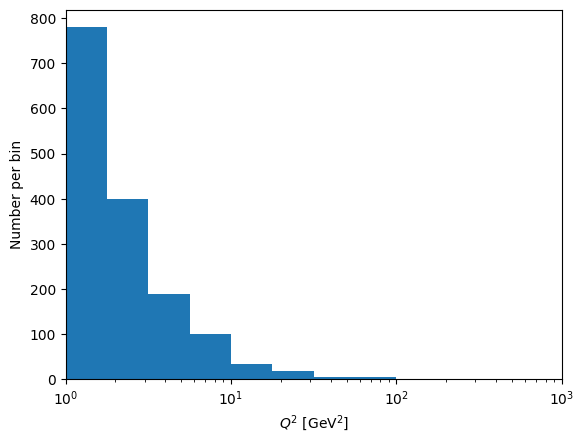

In [9]:
Q2bins= np.array([1.0, 1.77828, 3.16228, 5.62341, 10,17.7828, 31.6228, 56.2341, 100,177.828, 316.228, 562.341,1000.0,10000.0])
xBbins = np.array([1e-05,1.58489e-05,2.51189e-05,3.98107e-05,6.30957e-05,0.0001,0.000158489,0.000251189,0.000398107,0.000630957,0.001,0.00158489,0.00251189,
                   0.00398107,0.00630957,0.01,0.0158489,0.0251189,0.0398107,0.0630957,0.1,0.158489,0.251189,0.398107,0.630957,1])
ybins = np.array([0,0.01,0.02,0.03,0.05,0.07,0.1,0.15,0.2,0.3,0.4,0.6,1.0])
W2bins = np.array([0,200,400,600,800,1200,1500,2200,3000,4000,6800])

# Plot the Q2 distribution
print("Plotting Q2")
# Choose style of figure
style = {'facecolor': 'C0', 'edgecolor': 'none', 'linewidth': 1}
fig, ax = plt.subplots()
# Define what is going to be plotted, i.e., the distribution of mcQ2, using the binning defined by Q2bins
ax.hist(mcQ2_ar, bins=Q2bins, **style)
# Set the x and y axis labels
ax.set_xlabel('$Q^2$ [GeV$^2]$')
ax.set_ylabel('Number per bin')
# The binning here extends up to 10^4, but at the lowest COM energy, we do not reach so high, hence we limit the range of the x axis.
plt.xlim(1,1000)
#visualisation is better with a log scale.
plt.xscale('log')
plt.show()

#### Exercise: 
-  Plot the distribution of $x_B$, $W^2$ and $y$ for the simulated data, using the binning defined above.

#### Homework: 
- Use different input files, containing data generated at higher centre-of-mass energy, by adapting the path fpath as
  fpath = '/volatile/eic/EPIC/RECO/25.04.1/epic_craterlake/DIS/NC/18x275/minQ2=1/' and
  the input file name fname as
  fname="/home/jovyan/eic/input_18x275/input"+str(i)+".root",
  and plot again the $Q^2$, $x_B$ and $W^2$ distributions. You will need to run over at least 5 input files to collect sufficient
  statistics. Compare with the figures above. What do you notice?

#### Exercise: 
-  Draw the Q2 distributions as a function of the $x_B$ distribution for simulated data, expanding the code above to the drawing of a
   2D histogram, as seen in the tutorial section Working_With_Simulation_Output.

   Do you notice a correlation between $x_B$ and $Q^2$?

#### Exercise: 
-  Draw the reconstructed $Q^2$ distribution versus the generated $Q^2$ distribution and likewise for $x_B$.
   This gives you an idea about the resolution of these two kinematic variables.

## Including hadrons

Now we are going to expand the code to extract hadrons and plot their distribution in z. We will concentrate on positive pions and kaons. We will make sure that we start both for simulated and reconstructed from the same sample of DIS events, but for the selection of hadrons from this sample, we will select the reconstructed and generated hadrons separately in order to get an idea of the selection efficiency.

In [16]:
#Prepare the arrays in which we are going to store the kinematic variables, based on MC data and based on reconstructed data.
mcz_pion_ar = []
recz_pion_ar = []
mcz_kaon_ar = []
recz_kaon_ar = []
#When only looping over all 5 downloaded input files
#for entry in sorted(flist):
#When only looping over the first file
for entry in sorted(flist)[0:1]:
    tree=file['events']
    
    #MC info
    mcbranch=tree["MCParticles"].arrays()
    mcpdg=mcbranch["MCParticles.PDG"]
    mcgenstat=mcbranch["MCParticles.generatorStatus"]
    mcmass=mcbranch["MCParticles.mass"]
    mcp=vector.zip({'px':mcbranch["MCParticles.momentum.x"],'py':mcbranch["MCParticles.momentum.y"],'pz':mcbranch["MCParticles.momentum.z"]})
    
    #Starting point of list containing indices of parent particles
    mcparb=mcbranch["MCParticles.parents_begin"]
    #End point of list containing indices of parent particles
    mcpare=mcbranch["MCParticles.parents_end"]
    #Index of parent particle
    mcpar=mcbranchPar["_MCParticles_parents.index"]
    
    #Rec info
    recbranch=tree["ReconstructedChargedParticles"].arrays()
    recp=vector.zip({'px':recbranch["ReconstructedChargedParticles.momentum.x"],'py':recbranch["ReconstructedChargedParticles.momentum.y"],'pz':recbranch["ReconstructedChargedParticles.momentum.z"]})
    rece=recbranch["ReconstructedChargedParticles.energy"]
    relbranch = tree["ReconstructedChargedParticleAssociations"].arrays()
    relsimID=relbranch["ReconstructedChargedParticleAssociations.simID"]
    relrecID=relbranch["ReconstructedChargedParticleAssociations.recID"]
    
    #loop over events
    for i in range(len(mcbranch)):
    #for a quick test when looping over 100 events
    #for i in range(100):
        ##Select MC information we need
        #index for MC beam proton, beam lepton and scattered lepton: 
        mcid_p=-999
        mcid_e=-999
        mcid_escat=-999
        #print("\nsearch for beam proton")
        for j in range(len(mcpdg[i])):
            if ((mcpdg[i][j]==2212) & (mcgenstat[i][j]==4)):
                 #print("--> beam proton found")
                 mcid_p=j
                 break
        #print("search for beam lepton")          
        for j in range(len(mcpdg[i])):
            if ((mcpdg[i][j]==11) & (mcgenstat[i][j]==4)):
                 #print("--> beam lepton found")
                 mcid_e=j 
                 break
        #print("search for scattered beam lepton") 
        for j in range(len(mcpdg[i])):
            if mcid_escat>-999:
                break
            if((mcpdg[i][j]==11) & (mcgenstat[i][j]==1)):
            #loop over parent particles
                for k in range(mcparb[i][j], mcpare[i][j]):
                    if mcid_escat>-999:
                        break
                    ind=mcpar[i][k]
                    #print("Parent PID genstat ", mcpdg[i][ind], mcgenstat[i][ind])
                    if ((mcgenstat[i][ind]==4) & (mcpdg[i][ind]==11)):
                        #print("--> scattered lepton found")
                        mcid_escat=j
                    # maybe not the parent but the grandparent is the scattered beam lepton.
                    # In principle the loop can go on, but in the present simulation it is sufficient to look at grandparents
                    else:
                        for l in range(mcparb[i][ind], mcpare[i][ind]):
                            ind2=mcpar[i][l]
                            if ((mcgenstat[i][ind2]==4) & (mcpdg[i][ind2]==11)):
                                #print("--> scattered lepton found")
                                mcid_escat=j
                                break                     
        if((mcid_p==-999) | (mcid_e==-999) | (mcid_escat==-999)):
            continue
        ##Select Rec information we need
    	#Search for reconstructred scattered electron
        #It will be identified for the moment by navigating to the generated scattered lepton
        recid_e=-999
        for k in range(len(relrecID[i])):
            if((relsimID[i][k]==mcid_escat)):
                recid_e=relrecID[i][k]
                break
        if(recid_e==-999):
            continue
            
        ## We are in a position now to construct four-momentum vectors for our beam proton, beam lepton and scattered lepton and to 
        ## easily calculate the necessary DIS variables
        #beam proton
        en=math.sqrt(mcp[i][mcid_p].px**2+mcp[i][mcid_p].py**2+mcp[i][mcid_p].pz**2+mcmass[i][mcid_p]**2)
        m4p = np.array([en,mcp[i][mcid_p].px,mcp[i][mcid_p].py,mcp[i][mcid_p].pz])
        #print(mp4[0],mp4[1],mp4[2],mp4[3])
        #beam lepton
        en=math.sqrt(mcp[i][mcid_e].px**2+mcp[i][mcid_e].py**2+mcp[i][mcid_e].pz**2+mcmass[i][mcid_e]**2)
        m4e=np.array([en,mcp[i][mcid_e].px,mcp[i][mcid_e].py,mcp[i][mcid_e].pz])
        #mc scat lepton
        en=math.sqrt(mcp[i][mcid_escat].px**2+mcp[i][mcid_escat].py**2+mcp[i][mcid_escat].pz**2+mcmass[i][mcid_escat]**2)
        m4escatmc=np.array([en,mcp[i][mcid_escat].px,mcp[i][mcid_escat].py,mcp[i][mcid_escat].pz])
        ##rec scat lepton
        en=math.sqrt(recp[i][recid_e].px**2+recp[i][recid_e].py**2+recp[i][recid_e].pz**2+mcmass[i][recid_e]**2)
        m4escatrec=np.array([en,recp[i][recid_e].px,recp[i][recid_e].py,recp[i][recid_e].pz])

        #Obtain virtual photon vector
        m4qmc=m4e-m4escatmc
        m4qrec=m4e-m4escatrec
        
        #Calculate DIS variables
        mcQ2=-(m4qmc[0]*m4qmc[0]-m4qmc[1]*m4qmc[1]-m4qmc[2]*m4qmc[2]-m4qmc[3]*m4qmc[3])     
        recQ2=-(m4qrec[0]*m4qrec[0]-m4qrec[1]*m4qrec[1]-m4qrec[2]*m4qrec[2]-m4qrec[3]*m4qrec[3])
        mcxB=mcQ2/(2*(m4p[0]*m4qmc[0]-m4p[1]*m4qmc[1]-m4p[2]*m4qmc[2]-m4p[3]*m4qmc[3]))
        recxB=recQ2/(2*(m4p[0]*m4qrec[0]-m4p[1]*m4qrec[1]-m4p[2]*m4qrec[2]-m4p[3]*m4qrec[3]))
        #Calculate y
        mcy=((m4p[0]*m4qmc[0]-m4p[1]*m4qmc[1]-m4p[2]*m4qmc[2]-m4p[3]*m4qmc[3])/(m4p[0]*m4e[0]-m4p[1]*m4e[1]-m4p[2]*m4e[2]-m4p[3]*m4e[3]))
        recy=((m4p[0]*m4qrec[0]-m4p[1]*m4qrec[1]-m4p[2]*m4qrec[2]-m4p[3]*m4qrec[3])/(m4p[0]*m4e[0]-m4p[1]*m4e[1]-m4p[2]*m4e[2]-m4p[3]*m4e[3]))
        mcW2=mcmass[i][mcid_p]**2+(1-mcxB)*mcQ2/mcxB
        recW2=mcmass[i][mcid_p]**2+(1-recxB)*recQ2/recxB 

        #Apply DIS cuts        
        if((mcQ2<1) | (mcW2<10) | (mcy<0.01) | (mcy>0.95)):
            continue
        if((recQ2<1) | (recW2<10) | (recy<0.01) | (recy>0.95)):
            continue

        #loop over generated hadrons, selecting the stable particles
        for j in range(len(mcpdg[i])):
            if (((mcpdg[i][j]==211) | (mcpdg[i][j]==321)) & (mcgenstat[i][j]==1)):
                 en=math.sqrt(mcp[i][j].px**2+mcp[i][j].py**2+mcp[i][j].pz**2+mcmass[i][j]**2)
                 m4h = np.array([en,mcp[i][j].px,mcp[i][j].py,mcp[i][j].pz])
                 z=((m4p[0]*m4h[0]-m4p[1]*m4h[1]-m4p[2]*m4h[2]-m4p[3]*m4h[3])/(m4p[0]*m4qmc[0]-m4p[1]*m4qmc[1]-m4p[2]*m4qmc[2]-m4p[3]*m4qmc[3]))
                 if(mcpdg[i][j]==211):
                    mcz_pion_ar.append(z)
                 if(mcpdg[i][j]==321):
                    mcz_kaon_ar.append(z)
        #loop over the reconstructed hadrons
        for j in range(len(rece[i])):
            id=-999
            # Search for corresponding simulated particle in order to obtain its PID.
            # in a later step, as used in real data, reconstructed PID information will be available, but at the moment it is not implemented
            for k in range(len(relsimID[i])):
                if(relrecID[i][k]==j):
                    id=relsimID[i][k]
            if(id==-999):       
                continue
            en=math.sqrt(recp[i][j].px**2+recp[i][j].py**2+recp[i][j].pz**2+mcmass[i][id]**2)
            m4h = np.array([en,recp[i][j].px,recp[i][j].py,recp[i][j].pz])
            z=((m4p[0]*m4h[0]-m4p[1]*m4h[1]-m4p[2]*m4h[2]-m4p[3]*m4h[3])/(m4p[0]*m4qrec[0]-m4p[1]*m4qrec[1]-m4p[2]*m4qrec[2]-m4p[3]*m4qrec[3]))
            if(mcpdg[i][id]==211):
                recz_pion_ar.append(z)
            if(mcpdg[i][id]==321):
                recz_kaon_ar.append(z)

#### Exercise: 
-   Plot the z distribution for generated and reconstructed pions on 1 plot and same for kaons, using as binning:
[0.,0.05,0.1,0.15,0.2,0.25,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]